# MSE 446 Project - Team 2
## GMM Song Recommendation Model
Loads cleaned data from  (produced by ).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned dataset produced by MSE446_Group2_DataCleaning.ipynb
songs = pd.read_csv("datasets/songs_cleaned.csv")
print(f"Loaded {len(songs)} songs with {songs.shape[1]} features")
songs.head()

Loaded 4493 songs with 150 features


,track_id,energy,tempo,danceability,loudness,liveness,valence,track_artist,speechiness,track_popularity,...,playlist_genre_pop,playlist_genre_punk,playlist_genre_r&b,playlist_genre_reggae,playlist_genre_rock,playlist_genre_soca,playlist_genre_soul,playlist_genre_turkish,playlist_genre_wellness,playlist_genre_world
0,00Coyxt9mTec1acC52qtWa,0.736420,0.329870,0.634822,0.898334,0.083507,0.502,TAEIL,0.009170,0.494382,...,0,0,0,0,0,0,0,0,0,0
1,00DPAwQ3NkWs6PZKNxy7Pi,0.899779,0.433735,0.782632,0.880394,0.168058,0.675,Olamilekan Akamo,0.069716,0.213483,...,0,0,0,0,0,0,0,0,0,0
2,00Gbi2ytn6ZmA1ObVcPT93,0.928843,0.454284,0.579394,0.866443,0.670146,0.678,Smith & Thell,0.024307,0.224719,...,1,0,0,0,0,0,0,0,0,0
3,00JOgmWv6RmkgwPxdYScnf,0.472839,0.480056,0.387023,0.748780,0.200418,0.067,Greg Edmonson,0.017015,0.179775,...,0,0,0,0,0,0,0,0,0,0
4,00Mb3DuaIH1kjrwOku9CGU,0.901784,0.526440,0.465276,0.883876,0.351775,0.484,Avril Lavigne,0.029058,0.741573,...,0,1,0,0,0,0,0,0,0,0


In [6]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity

# -------------------------------
# GMM-BASED SONG RECOMMENDER
# -------------------------------

songs_gmm = songs.copy()

# Audio features used for GMM (excludes popularity — model is blind to fame)
base_features = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'acousticness', 'instrumentalness'
]

genre_cols   = [c for c in songs_gmm.columns if c.startswith('playlist_genre_')]
time_sig_cols = [c for c in songs_gmm.columns if c.startswith('time_signature_')]

feature_cols = base_features + genre_cols + time_sig_cols

missing = [c for c in feature_cols if c not in songs_gmm.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

songs_gmm[feature_cols] = songs_gmm[feature_cols].astype(float)

# Primary artist (first listed)
songs_gmm['primary_artist'] = (
    songs_gmm['track_artist'].fillna('').str.split(',').str[0].str.strip()
)

# --- Fit GMM ---
n_components = 8
X = songs_gmm[feature_cols].to_numpy()

gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
gmm.fit(X)

# Hard cluster assignment (most likely component)
songs_gmm['gmm_cluster'] = gmm.predict(X)

# Soft cluster probabilities — shape (n_songs, n_components)
# These are the true GMM posteriors: P(component k | song)
cluster_probs = gmm.predict_proba(X)
prob_cols = [f'gmm_prob_{i}' for i in range(n_components)]
songs_gmm[prob_cols] = cluster_probs

print(f"GMM fitted: {n_components} components, {len(feature_cols)} features.")
print(f"Songs per cluster:\n{songs_gmm['gmm_cluster'].value_counts().sort_index().to_string()}")


GMM fitted: 8 components, 47 features.
Songs per cluster:
gmm_cluster
0     541
1    1019
2    1093
3     409
4     370
5     346
6     256
7     459


## Section 1: GMM Hyperparameter Tuning (BIC)

Grid-search over `n_components` and `covariance_type`. The model with the lowest BIC is selected and refitted; all downstream cells use the tuned model.

Fitting 24 GMM models …

BIC results (sorted ascending):
 n_components covariance_type           bic           aic
           16            diag -1.733296e+06 -1.743033e+06
           16            full -1.621292e+06 -1.741901e+06
           12            diag -1.533059e+06 -1.540361e+06
           10            diag -1.506638e+06 -1.512721e+06
           12            full -1.463599e+06 -1.554055e+06
           10            full -1.443846e+06 -1.519224e+06
            8            diag -1.413751e+06 -1.418617e+06
            6            diag -1.386237e+06 -1.389885e+06
            8            full -1.370395e+06 -1.430697e+06
            6            full -1.333126e+06 -1.378350e+06
            4            diag -1.138044e+06 -1.140473e+06
            4            full -1.137095e+06 -1.167243e+06
           16            tied -6.949599e+05 -7.071074e+05
           12            tied -6.928382e+05 -7.037549e+05
           10            tied -5.935571e+05 -6.038584e+05
            8  

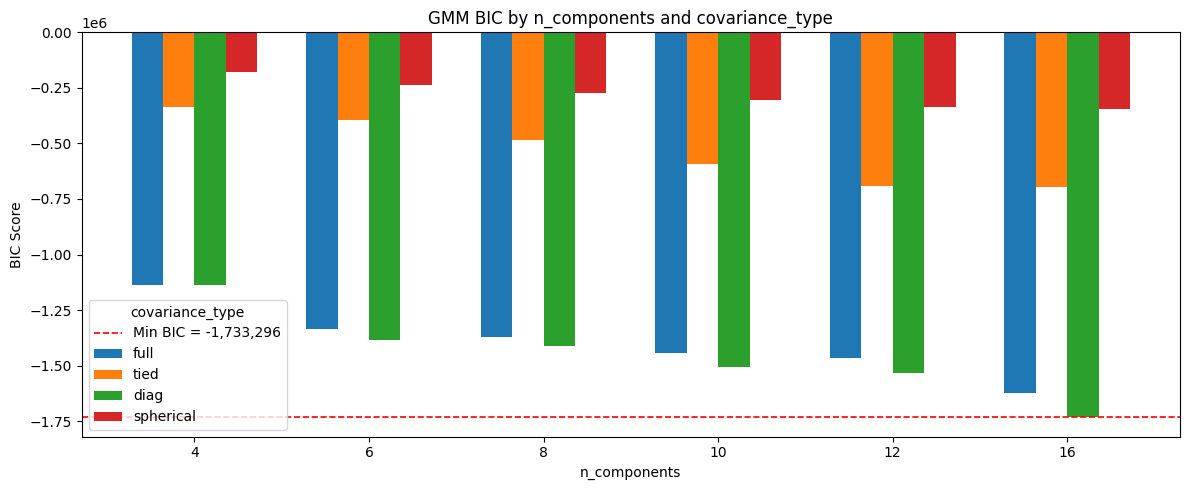


Best model: n_components=16, covariance_type='diag' (BIC=-1,733,295.9)

Refitted GMM: 16 components, covariance_type='diag', 47 features.
Songs per cluster:
gmm_cluster
0     503
1     135
2     303
3     385
4     363
5     194
6     172
7     446
8     353
9     284
10    374
11     78
12    420
13    133
14    179
15    171


In [7]:
# ---------------------------------------------------------------
# SECTION 1 — GMM HYPERPARAMETER TUNING (BIC / AIC GRID SEARCH)
# ---------------------------------------------------------------
import itertools

n_components_grid  = [4, 6, 8, 10, 12, 16]
covariance_types   = ['full', 'tied', 'diag', 'spherical']

rows = []
total = len(n_components_grid) * len(covariance_types)
print(f"Fitting {total} GMM models …")

for k, cov in itertools.product(n_components_grid, covariance_types):
    g = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
    g.fit(X)
    rows.append({
        'n_components':    k,
        'covariance_type': cov,
        'bic':             g.bic(X),
        'aic':             g.aic(X),
    })

bic_results = pd.DataFrame(rows).sort_values('bic').reset_index(drop=True)
print("\nBIC results (sorted ascending):")
print(bic_results.to_string(index=False))

# ── Grouped bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x_vals   = sorted(bic_results['n_components'].unique())
cov_list = covariance_types
n_cov    = len(cov_list)
bar_w    = 0.18
offsets  = [bar_w * (i - (n_cov - 1) / 2) for i in range(n_cov)]

for i, cov in enumerate(cov_list):
    sub = bic_results[bic_results['covariance_type'] == cov].set_index('n_components')
    y   = [sub.loc[k, 'bic'] if k in sub.index else float('nan') for k in x_vals]
    x_pos = [j + offsets[i] for j, _ in enumerate(x_vals)]
    ax.bar(x_pos, y, width=bar_w, label=cov)

min_bic = bic_results['bic'].min()
ax.axhline(min_bic, color='red', linestyle='--', linewidth=1.2,
           label=f'Min BIC = {min_bic:,.0f}')

ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels(x_vals)
ax.set_xlabel('n_components')
ax.set_ylabel('BIC Score')
ax.set_title('GMM BIC by n_components and covariance_type')
ax.legend(title='covariance_type')
plt.tight_layout()
plt.show()

# ── Select best model and refit ──────────────────────────────────
best_row  = bic_results.iloc[0]
best_n    = int(best_row['n_components'])
best_cov  = best_row['covariance_type']
print(f"\nBest model: n_components={best_n}, covariance_type='{best_cov}' "
      f"(BIC={best_row['bic']:,.1f})")

# Refit global GMM with best hyperparameters
n_components = best_n
gmm = GaussianMixture(n_components=n_components, covariance_type=best_cov,
                      random_state=42)
gmm.fit(X)

# Update cluster assignments and soft posteriors in songs_gmm
songs_gmm['gmm_cluster'] = gmm.predict(X)

cluster_probs = gmm.predict_proba(X)
prob_cols     = [f'gmm_prob_{i}' for i in range(n_components)]

# Drop any stale prob columns from the previous fit
old_prob_cols = [c for c in songs_gmm.columns if c.startswith('gmm_prob_')]
songs_gmm.drop(columns=old_prob_cols, inplace=True)

songs_gmm[prob_cols] = cluster_probs

print(f"\nRefitted GMM: {n_components} components, "
      f"covariance_type='{best_cov}', {len(feature_cols)} features.")
print(f"Songs per cluster:\n"
      f"{songs_gmm['gmm_cluster'].value_counts().sort_index().to_string()}")

## Section 2: GMM vs Cosine Similarity Weight Testing

Sweep the GMM / cosine weight split across five combinations using the top-3 most popular songs as seeds. Evaluates recommendation quality (avg score) and underground discovery (avg artist top-track popularity — lower is better).

Seed songs for weight testing:
  • Die With A Smile
  • APT.
  • BIRDS OF A FEATHER

Weight testing results (averaged over seed songs):
 gmm_weight  avg_score  avg_gmm_sim  avg_cos_sim  avg_artist_top_track_popularity
       0.00   0.883050          1.0     0.883050                         0.322222
       0.25   0.912287          1.0     0.883050                         0.322222
       0.50   0.941525          1.0     0.883050                         0.322222
       0.75   0.970762          1.0     0.883050                         0.322222
       1.00   1.000000          1.0     0.794387                         0.282222


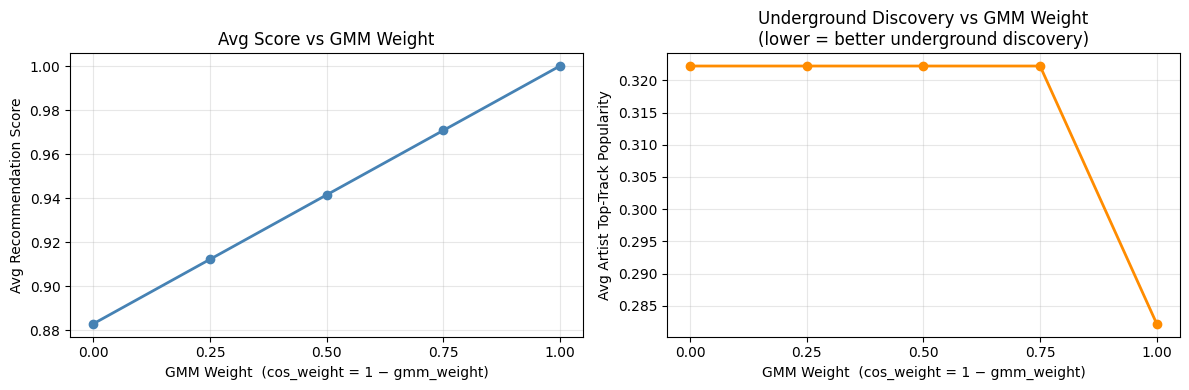


Best weight combo for highest avg score:
  gmm_weight=1.00, cos_weight=0.00  → avg_score=1.0000

Best weight combo for underground discovery (lowest avg popularity):
  gmm_weight=1.00, cos_weight=0.00  → avg_artist_top_track_popularity=0.2822


In [8]:
# ---------------------------------------------------------------
# SECTION 2 — GMM vs COSINE SIMILARITY WEIGHT TESTING
# ---------------------------------------------------------------

# ── Weight combinations to test ────────────────────────────────────
# Each tuple: (gmm_weight, cos_weight)
weight_combos = [(0.0, 1.0), (0.25, 0.75), (0.5, 0.5), (0.75, 0.25), (1.0, 0.0)]

# ── Fixed seed songs: top 3 by track_popularity ────────────────────
top3_seeds = (
    songs_gmm.sort_values('track_popularity', ascending=False)
    .drop_duplicates('track_name')
    .head(3)['track_name']
    .tolist()
)
print("Seed songs for weight testing:")
for s in top3_seeds:
    print(f"  • {s}")

# ── Inline recommendation loop ──────────────────────────────────
detail_rows = []

for gmm_w, cos_w in weight_combos:
    for seed_name in top3_seeds:
        # Locate seed row (exact match, pick most popular)
        mask    = songs_gmm['track_name'].str.lower() == seed_name.lower()
        matches = songs_gmm[mask]
        if matches.empty:
            continue
        seed_row   = matches.sort_values('track_popularity', ascending=False).iloc[0]
        seed_vec   = seed_row[feature_cols].to_numpy(dtype=float).reshape(1, -1)
        seed_probs = seed_row[prob_cols].to_numpy(dtype=float)

        # Candidate pool: small artists only, exclude seed
        candidates = songs_gmm[
            (songs_gmm['artist_top_track_popularity'] < SMALL_ARTIST_THRESHOLD) &
            (songs_gmm['track_id'] != seed_row['track_id'])
        ].copy()

        if candidates.empty:
            continue

        # Score candidates
        cand_probs  = candidates[prob_cols].to_numpy(dtype=float)
        gmm_sim     = cand_probs @ seed_probs
        cand_feats  = candidates[feature_cols].to_numpy(dtype=float)
        cos_sim     = cosine_similarity(seed_vec, cand_feats).flatten()

        score = gmm_w * gmm_sim + cos_w * cos_sim

        # Top 3 recommendations
        top_idx  = score.argsort()[::-1][:3]
        top_cands = candidates.iloc[top_idx].copy()
        top_cands['_score']   = score[top_idx]
        top_cands['_gmm_sim'] = gmm_sim[top_idx]
        top_cands['_cos_sim'] = cos_sim[top_idx]

        detail_rows.append({
            'gmm_weight':                    gmm_w,
            'cos_weight':                    cos_w,
            'seed_song':                     seed_name,
            'avg_score':                     top_cands['_score'].mean(),
            'avg_gmm_sim':                   top_cands['_gmm_sim'].mean(),
            'avg_cos_sim':                   top_cands['_cos_sim'].mean(),
            'avg_artist_top_track_popularity': top_cands['artist_top_track_popularity'].mean(),
        })

detail_df = pd.DataFrame(detail_rows)

# ── Aggregate by gmm_weight (mean over 3 seeds) ────────────────────
weight_results = (
    detail_df
    .groupby('gmm_weight')[
        ['avg_score', 'avg_gmm_sim', 'avg_cos_sim',
         'avg_artist_top_track_popularity']
    ]
    .mean()
    .reset_index()
)
print("\nWeight testing results (averaged over seed songs):")
print(weight_results.to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: avg_score vs gmm_weight
ax1.plot(weight_results['gmm_weight'], weight_results['avg_score'],
         marker='o', linewidth=2, color='steelblue')
ax1.set_xlabel('GMM Weight  (cos_weight = 1 − gmm_weight)')
ax1.set_ylabel('Avg Recommendation Score')
ax1.set_title('Avg Score vs GMM Weight')
ax1.set_xticks(weight_results['gmm_weight'])
ax1.grid(True, alpha=0.3)

# Right: avg_artist_top_track_popularity vs gmm_weight
ax2.plot(weight_results['gmm_weight'],
         weight_results['avg_artist_top_track_popularity'],
         marker='o', linewidth=2, color='darkorange')
ax2.set_xlabel('GMM Weight  (cos_weight = 1 − gmm_weight)')
ax2.set_ylabel('Avg Artist Top-Track Popularity')
ax2.set_title('Underground Discovery vs GMM Weight\n(lower = better underground discovery)')
ax2.set_xticks(weight_results['gmm_weight'])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Report best combos ───────────────────────────────────────────
best_score_row   = weight_results.loc[weight_results['avg_score'].idxmax()]
best_underground = weight_results.loc[
    weight_results['avg_artist_top_track_popularity'].idxmin()
]

print(f"\nBest weight combo for highest avg score:")
print(f"  gmm_weight={best_score_row['gmm_weight']:.2f}, "
      f"cos_weight={1 - best_score_row['gmm_weight']:.2f}  "
      f"→ avg_score={best_score_row['avg_score']:.4f}")

print(f"\nBest weight combo for underground discovery (lowest avg popularity):")
print(f"  gmm_weight={best_underground['gmm_weight']:.2f}, "
      f"cos_weight={1 - best_underground['gmm_weight']:.2f}  "
      f"→ avg_artist_top_track_popularity={best_underground['avg_artist_top_track_popularity']:.4f}")

In [9]:
# ---------------------------------------------------------------
# GMM RECOMMENDATION FUNCTION
# ---------------------------------------------------------------
# "Small artist" = artist whose best-known track has popularity
# below this threshold (0–1 scale; 0.6 → top track scored < 60/100)
SMALL_ARTIST_THRESHOLD = 0.6


def recommend_small_artists_gmm(input_song, input_artist=None, n_recs=3,
                                  gmm_weight=0.5, cos_weight=0.5):
    """
    Recommend songs from smaller/underground artists that are musically
    similar to a given popular input song.

    How it uses the GMM properly:
      Each song has a soft cluster distribution P(component k | song)
      computed from gmm.predict_proba().  Similarity between two songs
      is measured as the dot product of their cluster probability vectors:

          GMM_sim(seed, candidate) = Σ_k  P(k|seed) · P(k|candidate)

      This is a proper probabilistic measure: it is high when both songs
      have high probability mass on the same latent audio components.
      It is combined with cosine similarity in raw feature space using
      the supplied weights.

    Parameters
    ----------
    input_song   : str   — track name of the seed (popular) song
    input_artist : str   — (optional) artist name to disambiguate
    n_recs       : int   — number of recommendations to return (default 3)
    gmm_weight   : float — weight applied to GMM posterior similarity (default 0.5)
    cos_weight   : float — weight applied to cosine feature similarity (default 0.5)
                           gmm_weight + cos_weight need not equal 1, but typically do.

    Returns
    -------
    seed : pd.Series       — the matched seed song row
    recs : pd.DataFrame    — top-n recommended songs
    """

    # 1. Find the seed song ----------------------------------------
    mask = songs_gmm['track_name'].str.lower() == input_song.lower()
    matches = songs_gmm[mask].copy()

    if input_artist:
        am = matches['track_artist'].str.lower().str.contains(
            input_artist.lower(), na=False
        )
        if am.any():
            matches = matches[am]

    # Fallback: partial name match
    if matches.empty:
        mask = songs_gmm['track_name'].str.lower().str.contains(
            input_song.lower(), na=False
        )
        matches = songs_gmm[mask].copy()

    if matches.empty:
        raise ValueError(f"Song '{input_song}' not found in dataset.")

    # Use the most popular match as the seed
    seed = matches.sort_values('track_popularity', ascending=False).iloc[0]

    seed_vec   = seed[feature_cols].to_numpy(dtype=float).reshape(1, -1)
    seed_probs = seed[prob_cols].to_numpy(dtype=float)   # (n_components,)

    # 2. Candidate pool: small artists only, exclude seed ----------
    candidates = songs_gmm[
        (songs_gmm['artist_top_track_popularity'] < SMALL_ARTIST_THRESHOLD) &
        (songs_gmm['track_id'] != seed['track_id'])
    ].copy()

    if candidates.empty:
        raise ValueError(
            f"No small-artist songs found (threshold={SMALL_ARTIST_THRESHOLD})."
        )

    # 3. Score candidates ------------------------------------------
    # (a) Proper GMM similarity: dot product of posterior distributions
    cand_probs  = candidates[prob_cols].to_numpy(dtype=float)   # (n, n_components)
    gmm_sim     = cand_probs @ seed_probs                        # (n,)

    # (b) Cosine similarity in audio feature space
    cand_feats  = candidates[feature_cols].to_numpy(dtype=float)
    cos_sim     = cosine_similarity(seed_vec, cand_feats).flatten()

    # (c) Combined score — weighted blend of GMM and cosine similarity
    candidates['gmm_similarity'] = gmm_sim
    candidates['cos_similarity'] = cos_sim
    candidates['score']          = gmm_weight * gmm_sim + cos_weight * cos_sim

    # 4. Return top n_recs -----------------------------------------
    recs = (
        candidates
        .sort_values('score', ascending=False)
        .head(n_recs)
        [['track_name', 'track_artist', 'track_popularity',
          'artist_top_track_popularity', 'gmm_cluster',
          'gmm_similarity', 'cos_similarity', 'score']]
        .reset_index(drop=True)
    )

    return seed, recs


# ---------------------------------------------------------------
# DEMO  — change input_song to any track in the dataset
# ---------------------------------------------------------------
input_song   = "Don't Cry (Original)"
input_artist = None          # set e.g. "Tate McRae" to disambiguate

seed, recs = recommend_small_artists_gmm(
    input_song, input_artist=input_artist, n_recs=3
)

print("=" * 62)
print("INPUT SONG")
print(f"  Title  : {seed['track_name']}")
print(f"  Artist : {seed['track_artist']}")
print(f"  Track popularity          : {seed['track_popularity']:.2f}")
print(f"  Artist top-track pop.     : {seed['artist_top_track_popularity']:.2f}")
print(f"  GMM cluster               : {seed['gmm_cluster']}")
print("=" * 62)
print(f"\nTOP {len(recs)} RECOMMENDATIONS FROM SMALLER ARTISTS\n")

for i, row in recs.iterrows():
    print(f"  {i+1}. \"{row['track_name']}\"  by  {row['track_artist']}")
    print(f"     Artist top-track popularity : {row['artist_top_track_popularity']:.2f}")
    print(f"     GMM sim : {row['gmm_similarity']:.4f}  |  "
          f"Cosine sim : {row['cos_similarity']:.4f}  |  "
          f"Score : {row['score']:.4f}")
    print()

INPUT SONG
  Title  : Don't Cry (Original)
  Artist : Guns N' Roses
  Track popularity          : 0.72
  Artist top-track pop.     : 0.84
  GMM cluster               : 2

TOP 3 RECOMMENDATIONS FROM SMALLER ARTISTS

  1. "My Girl"  by  Mayflower
     Artist top-track popularity : 0.28
     GMM sim : 1.0000  |  Cosine sim : 0.9958  |  Score : 0.9979

  2. "Here Without You"  by  3 Doors Down
     Artist top-track popularity : 0.50
     GMM sim : 1.0000  |  Cosine sim : 0.9956  |  Score : 0.9978

  3. "Sad In Carolina"  by  Dexter and The Moonrocks
     Artist top-track popularity : 0.17
     GMM sim : 1.0000  |  Cosine sim : 0.9913  |  Score : 0.9957

